# Proyecto IA: Predicción de Rendimiento Académico

Este notebook desarrolla el análisis y el modelo de Regresión Lineal Múltiple para predecir el índice de rendimiento de estudiantes en la **Academia Nova**.

### 📌 Contexto del Problema y Preguntas de Negocio

La institución ha detectado una disparidad en el rendimiento de sus alumnos. Para diseñar tutorías personalizadas y estrategias de intervención temprana eficientes, buscamos responder científicamente a tres preguntas de negocio:

1. **¿Qué variable de los hábitos de estudio tiene mayor peso en el rendimiento final?**
2. **¿Cada hora adicional de estudio cuánto suma realmente al índice de rendimiento?**
3. **¿Vale la pena sacrificar horas de sueño por estudiar más?**

A lo largo del proyecto, utilizaremos técnicas de Aprendizaje Supervisado para dar respuesta a estas interrogantes mediante un modelo de regresión altamente interpretable.

## 1. Carga de Datos
Vamos a cargar el dataset desde Kaggle utilizando la librería `kagglehub` y lo cargaremos en un DataFrame de `pandas`.

In [1]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

# Carga del dataset desde Kaggle
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nikhil7280/student-performance-multiple-linear-regression",
  "Student_Performance.csv"
)

# Mostrar los primeros registros
df.head()

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 2. Preprocesamiento y Traducción de Variables
El algoritmo de Regresión Lineal Múltiple requiere que todas las variables sean numéricas. La variable `Extracurricular Activities` es categórica (Yes/No).

**¿Por qué usamos LabelEncoder y no get_dummies?**
Como la variable es estrictamente binaria (solo tiene dos opciones: Sí o No), usar `pd.get_dummies` nos crearía una columna extra redundante y caeríamos en la **"Trampa de Multicolinealidad"**. Para Regresión Lineal Múltiple, es más limpio usar `LabelEncoder` para transformar el Sí en 1 y el No en 0 en la misma columna.

Además, renombraremos las columnas al español para una mejor comprensión durante el análisis.

In [2]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Extracurricular Activities'] = encoder.fit_transform(df['Extracurricular Activities'])

print("Clases de 'Extracurricular Activities':", encoder.classes_)
print("El valor 'No' es 0 y 'Yes' es 1.\n")

# Traducir las columnas al español
df.rename(columns={
    'Hours Studied': 'Horas Estudiadas',
    'Previous Scores': 'Puntuaciones Previas',
    'Extracurricular Activities': 'Actividades Extracurriculares',
    'Sleep Hours': 'Horas de Sueño',
    'Sample Question Papers Practiced': 'Exámenes de Práctica',
    'Performance Index': 'Índice de Rendimiento'
}, inplace=True)

df.head()

Clases de 'Extracurricular Activities': ['No' 'Yes']
El valor 'No' es 0 y 'Yes' es 1.



,Horas Estudiadas,Puntuaciones Previas,Actividades Extracurriculares,Horas de Sueño,Exámenes de Práctica,Índice de Rendimiento
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## 3. Análisis Exploratorio de Datos (EDA)
Exploremos la estructura de nuestros datos, verifiquemos si hay valores nulos y observemos cómo se distribuyen nuestras variables numéricas utilizando histogramas.

In [3]:
print("Información general del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
df.describe()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Horas Estudiadas               10000 non-null  int64  
 1   Puntuaciones Previas           10000 non-null  int64  
 2   Actividades Extracurriculares  10000 non-null  int64  
 3   Horas de Sueño                 10000 non-null  int64  
 4   Exámenes de Práctica           10000 non-null  int64  
 5   Índice de Rendimiento          10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB

Estadísticas descriptivas:


,Horas Estudiadas,Puntuaciones Previas,Actividades Extracurriculares,Horas de Sueño,Exámenes de Práctica,Índice de Rendimiento
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


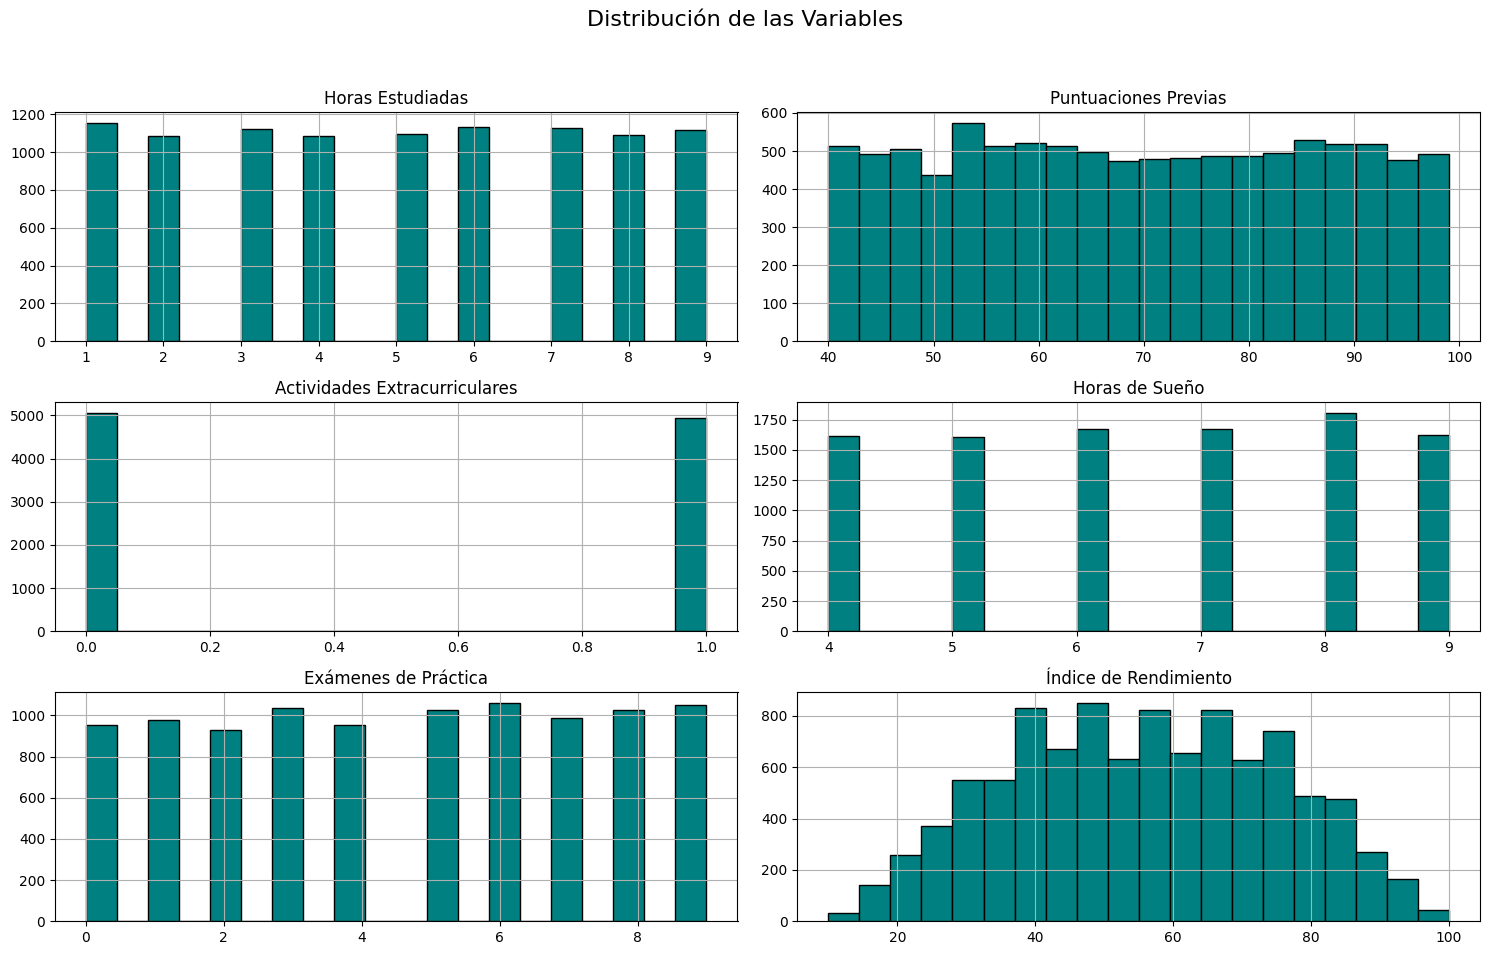

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de distribución para todas las variables
df.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Distribución de las Variables', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Visualización de Relaciones
Antes de crear el modelo, veamos visualmente cómo se correlacionan las variables independientes con nuestro objetivo (`Índice de Rendimiento`).

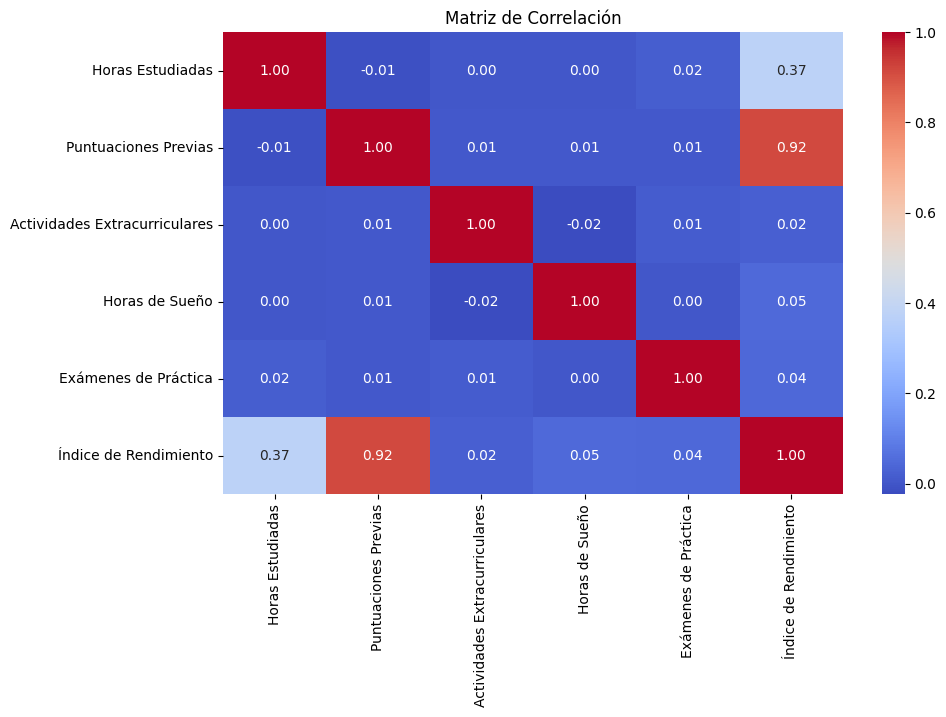

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

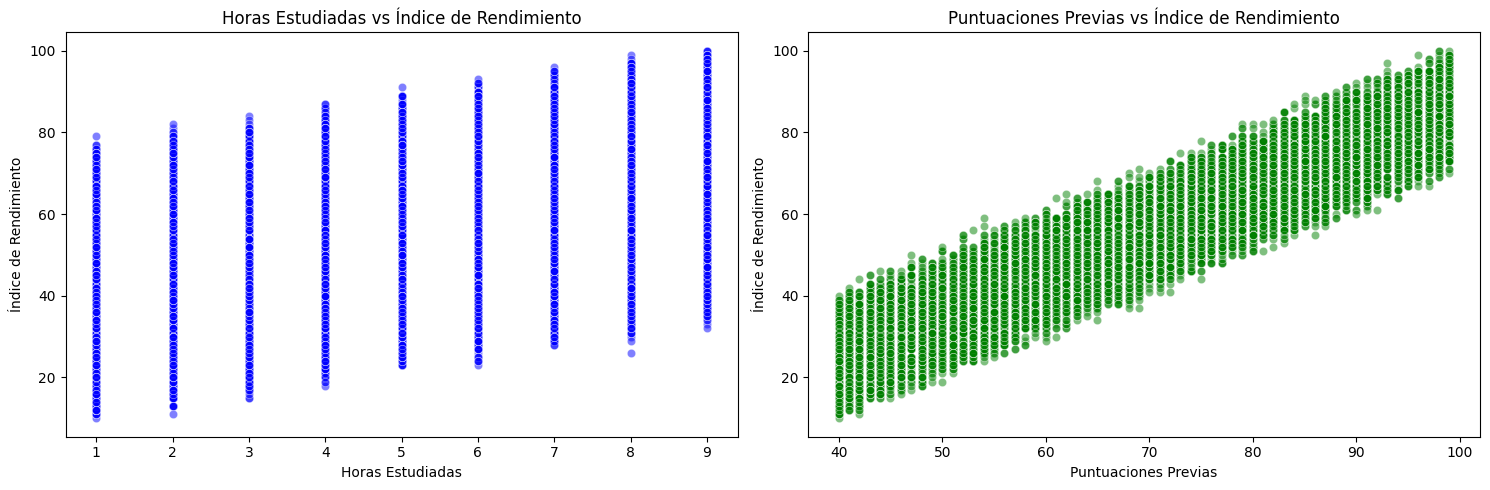

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='Horas Estudiadas', y='Índice de Rendimiento', ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title('Horas Estudiadas vs Índice de Rendimiento')

sns.scatterplot(data=df, x='Puntuaciones Previas', y='Índice de Rendimiento', ax=axes[1], color='green', alpha=0.5)
axes[1].set_title('Puntuaciones Previas vs Índice de Rendimiento')

plt.tight_layout()
plt.show()

## 5. Entrenamiento del Modelo de Regresión Lineal Múltiple
Separamos las variables predictoras (X) de la variable objetivo (y), y dividimos el dataset en entrenamiento y prueba.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Variables independientes
X = df.drop('Índice de Rendimiento', axis=1)
# Variable dependiente
y = df['Índice de Rendimiento']

# Dividir 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo (aquí se calculan matemáticamente los pesos)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Realizar predicciones con el set de prueba
y_pred = modelo.predict(X_test)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


## 6. Evaluación del Modelo (Rendimiento Visual y Numérico)
A diferencia de los problemas de Clasificación (donde se usa una Matriz de Confusión), en Regresión evaluamos el modelo con métricas de error y visualizando la diferencia entre los valores reales y nuestras predicciones.

Coeficiente de Determinación (R^2): 0.9890 (98.90%)
Error Cuadrático Medio (MSE): 4.0826


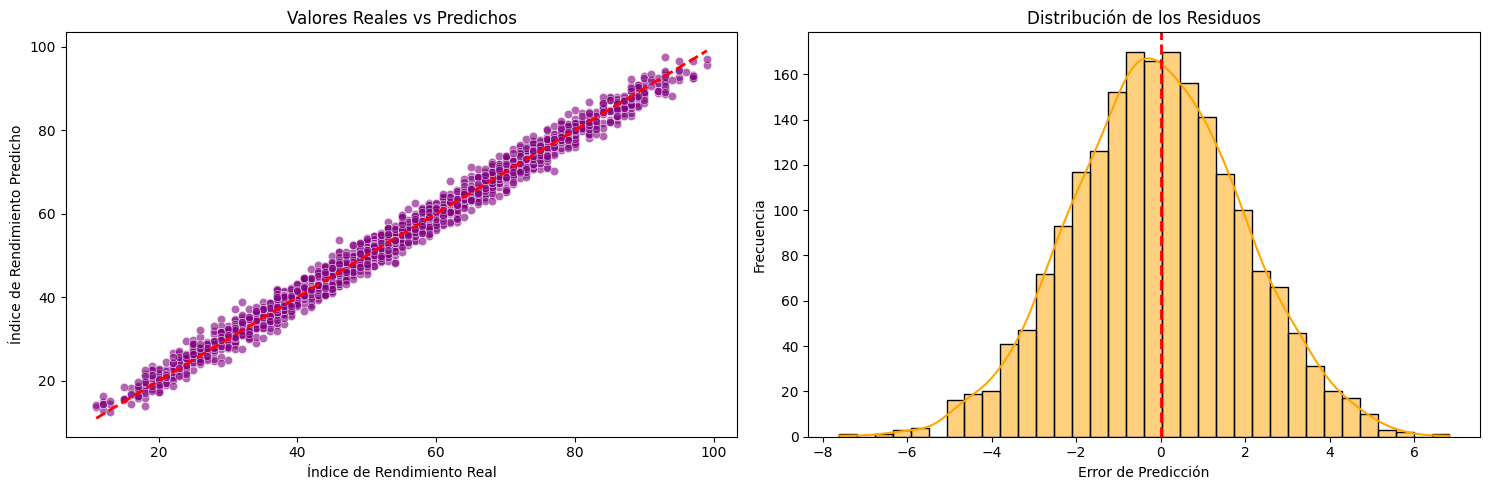

In [8]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Coeficiente de Determinación (R^2): {r2:.4f} ({r2*100:.2f}%)")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Valores Reales vs Predichos
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color='purple', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
axes[0].set_title('Valores Reales vs Predichos')
axes[0].set_xlabel('Índice de Rendimiento Real')
axes[0].set_ylabel('Índice de Rendimiento Predicho')

# Gráfico 2: Distribución de los Residuos (Errores)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, ax=axes[1], color='orange')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Distribución de los Residuos')
axes[1].set_xlabel('Error de Predicción')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Explicación de los resultados de evaluación (Para el negocio):
*   **¿Qué significa el $R^2$ de 98.9%?** Significa que nuestro modelo es casi perfecto. El 98.9% de la calificación final de un estudiante se puede explicar única y matemáticamente por estas 5 variables (horas de estudio, sueño, etc.).
*   **¿Qué nos dicen los gráficos?** En el primer gráfico (Reales vs Predichos), vemos que todos los puntos morados (alumnos evaluados) están extremadamente pegados a la línea roja diagonal de perfección. En el segundo gráfico (Distribución de Errores), vemos una 'campana' centrada exactamente en el cero, lo que significa que el modelo rara vez se equivoca, y cuando lo hace, el error es pequeñísimo.

## 7. Interpretación Matemática (La Ecuación del Modelo)
La mayor ventaja de la Regresión Lineal Múltiple es su **interpretabilidad**. A continuación, extraemos los pesos matemáticos reales para construir la ecuación de la Academia Nova.

In [9]:
intercepto = modelo.intercept_
coeficientes = modelo.coef_
variables = X.columns

df_coef = pd.DataFrame(coeficientes, variables, columns=['Coeficiente'])
print(df_coef.sort_values(by='Coeficiente', ascending=False))

ecuacion = f"Rendimiento = {intercepto:.2f}"
for coef, var in zip(coeficientes, variables):
    if coef >= 0:
        ecuacion += f" + {coef:.2f} * ({var})"
    else:
        ecuacion += f" - {abs(coef):.2f} * ({var})"

print("\n========================================================================================================")
print("ECUACIÓN FINAL DEL MODELO DE REGRESIÓN LINEAL")
print("========================================================================================================\n")
print(ecuacion)
print("\n========================================================================================================")

                               Coeficiente
Horas Estudiadas                  2.852484
Puntuaciones Previas              1.016988
Actividades Extracurriculares     0.608617
Horas de Sueño                    0.476941
Exámenes de Práctica              0.191831

ECUACIÓN FINAL DEL MODELO DE REGRESIÓN LINEAL

Rendimiento = -33.92 + 2.85 * (Horas Estudiadas) + 1.02 * (Puntuaciones Previas) + 0.61 * (Actividades Extracurriculares) + 0.48 * (Horas de Sueño) + 0.19 * (Exámenes de Práctica)



### Aclaración importante sobre los Coeficientes (Escala vs Importancia Real):
Si miramos la tabla, el coeficiente de `Horas Estudiadas` (~2.85) es mayor que el de `Puntuaciones Previas` (~1.02). Sin embargo, eso **no significa** que las horas de estudio tengan mayor impacto final. Esto ocurre porque las variables **no están en la misma escala**.
*   Las horas de estudio van de 1 a 9 (una unidad de cambio es grandísima a su escala, por eso vale 2.85 puntos).
*   Las puntuaciones previas van de 40 a 100 (una unidad de cambio es minúscula a su escala, pero si un alumno tiene 90, multiplicarlo por 1.02 aporta más de 91 puntos a su nota final).

Por lo tanto, la base académica histórica (Puntuaciones Previas) sigue siendo el factor más dominante, como vimos en el Heatmap de correlaciones al principio (0.92 de correlación).

## 8. Conclusiones Finales y Respuestas a la "Academia Nova"
Con nuestro modelo ya validado y explicado, podemos responder a las 3 preguntas clave que planteamos en la introducción de este proyecto:

1.  **¿Qué variable tiene mayor peso en el rendimiento final?**
    *   Observando nuestro Heatmap de correlación, la variable **Puntuaciones Previas** (Historial académico) es abrumadoramente el factor que más determina el éxito de un estudiante (correlación de 0.92). Una buena base académica es indispensable.

2.  **¿Cada hora adicional de estudio cuánto suma realmente al índice de rendimiento?**
    *   Gracias a nuestra Ecuación Matemática extraída, sabemos exactamente la respuesta: Manteniendo todo lo demás constante, estudiar 1 hora extra le suma **2.85 puntos** directos a la nota final del estudiante.

3.  **¿Vale la pena sacrificar horas de sueño por estudiar más?**
    *   El coeficiente de `Horas de Sueño` en nuestra ecuación es **+0.48**. Esto significa que dormir más *también* suma puntos al rendimiento cognitivo. Matemáticamente, estudiar aporta más puntos que dormir, pero reducir drásticamente el sueño resta puntos. La recomendación basada en datos para la academia es fomentar un **balance**: las horas de estudio son críticas, pero el buen dormir asegura décimas valiosas para alcanzar la excelencia.